#### MNIST FCN

Reparameterizes the dummy image using a sigmoid: Instead of directly optimizing over a variable representing an image (which may take values outside 0,1), we optimize an unconstrained variable and pass it through a sigmoid so that the dummy image is always in the valid range.

Increases the number of iterations: More updates sometimes help push the dummy image closer to the target.

Adds a slight regularization term: A total variation (TV) regularization term is added to encourage smoothness and promote natural-looking reconstructions.

Explanation:
- Reparameterization using Sigmoid: By optimizing dummy_param and then applying tf.sigmoid(dummy_param), we ensure that our dummy image always has pixel values between 0 and 1. This aligns our optimization with the natural image space.
- Extended Optimization Iterations: Increased iterations (set here to 1000) provide the optimizer more time to reduce the gradient difference. Depending on your setup, you might even experiment with more iterations.
- Total Variation Regularization: The added regularization term tf.image.total_variation(dummy_data) penalizes abrupt changes in the image, thereby promoting smoothness. The regularization weight (0.001) is modest, but you may tweak it based on the reconstruction quality and how much “smoothness” you intend to enforce.

Starting the reconstruction attack...
Iteration 0, Total loss: 258.0937
Iteration 100, Total loss: 85.5919
Iteration 200, Total loss: 41.8976
Iteration 300, Total loss: 9.5132
Iteration 400, Total loss: 1.4062
Iteration 500, Total loss: 1.2314
Iteration 600, Total loss: 1.1509
Iteration 700, Total loss: 1.1042
Iteration 800, Total loss: 1.0740
Iteration 900, Total loss: 1.0531


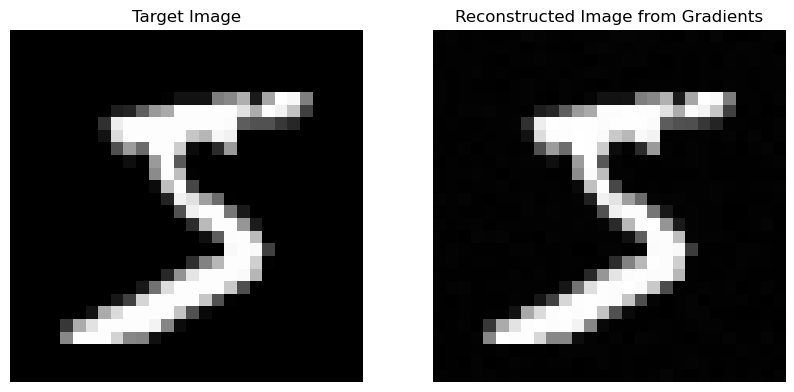

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
import numpy as np
import matplotlib.pyplot as plt

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

# -----------------------------------
# 1. Define a Simple Neural Network
# -----------------------------------
def create_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10)  # Logits for 10 classes
    ])
    return model

model = create_model()

# -----------------------------------
# 2. Load MNIST and Select a Target Sample
# -----------------------------------
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)  # Shape: (batch, 28, 28, 1)

# Choose one target sample
target_data = tf.convert_to_tensor(train_images[0:1])
target_label = tf.convert_to_tensor(train_labels[0:1])

# -----------------------------------
# 3. Compute the Target Gradients
# -----------------------------------
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

with tf.GradientTape() as tape:
    logits = model(target_data)
    target_loss = loss_fn(target_label, logits)
target_grads = tape.gradient(target_loss, model.trainable_variables)

# -----------------------------------
# 4. Simulate the Gradient Leakage Attack with Improvements
# -----------------------------------
# Instead of optimizing dummy data directly, we optimize an unconstrained variable that we
# transform through a sigmoid function to ensure the dummy image is in [0,1].
dummy_param = tf.Variable(tf.random.normal(shape=target_data.shape), trainable=True)

def get_dummy_image():
    # Enforces valid image pixel range
    return tf.sigmoid(dummy_param)

# Use Adam optimizer; you might adjust the learning rate and further fine-tune as needed.
optimizer = optimizers.Adam(learning_rate=0.1)

num_iterations = 1000  # Increased iterations for potentially better convergence

print("Starting the reconstruction attack...")
for i in range(num_iterations):
    with tf.GradientTape() as outer_tape:
        dummy_data = get_dummy_image()
        # Inner tape to compute gradients w.r.t. model parameters for dummy data
        with tf.GradientTape() as inner_tape:
            dummy_logits = model(dummy_data)
            dummy_loss = loss_fn(target_label, dummy_logits)
        dummy_grads = inner_tape.gradient(dummy_loss, model.trainable_variables)
        
        # Compute the L2 difference between dummy gradients and target gradients
        grad_diff = 0.0
        for dg, tg in zip(dummy_grads, target_grads):
            grad_diff += tf.reduce_sum(tf.square(dg - tg))
        
        # Add a regularization term: total variation loss to encourage smoothness.
        reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
        # The regularization weight (0.001) can be tweaked to balance reconstruction vs. smoothness.
        total_loss = grad_diff + 0.001 * reg_loss

    # Compute the gradient of the loss with respect to the dummy parameters (not the image directly).
    grad_dummy = outer_tape.gradient(total_loss, dummy_param)
    optimizer.apply_gradients([(grad_dummy, dummy_param)])
    
    if i % 100 == 0:
        print(f"Iteration {i}, Total loss: {total_loss.numpy():.4f}")

# -----------------------------------
# 5. Visualize the Results
# -----------------------------------
dummy_image = get_dummy_image().numpy().squeeze()   # Reconstructed image from gradients
target_image = target_data.numpy().squeeze()          # Original target image

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Target Image")
plt.imshow(target_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image from Gradients")
plt.imshow(dummy_image, cmap='gray')
plt.axis('off')

plt.show()


#### GCNN Circuit

Training the GCNN for node classification to predict one of the class (gate-type)  ['and', 'or', 'nand', 'nor', 'xor', 'xnor', 'buf', 'not'].

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    
    # Find nodes with fan-out > 0 (likely driving this gate)
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    
    # Assign 'fan_in' number of edges
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src → node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Remove invalid edges (if any)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops to avoid zero in-degree

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

C:\Users\rrk307\Anaconda3\lib\site-packages\dgl\backend\pytorch\tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


Epoch 0/50, Loss: 2.5170
Epoch 10/50, Loss: 1.1856
Epoch 20/50, Loss: 0.5843
Epoch 30/50, Loss: 0.3756
Epoch 40/50, Loss: 0.3059

✅ Test Accuracy: 92.21%

✅ Train Accuracy: 92.20%


In this demonstration, we assume that an attacker has access to the gradients computed from a target node during training. The attack works by treating the target node’s features as an unknown (dummy) variable and then optimizing that dummy variable so that the gradient computed with the dummy features closely matches the target gradients. In this example, we pick one target node (here, the first node from the train mask) and reconstruct its feature vector.

- Computing Target Gradients (Step 8A): We pick one target node (from the training set) and compute the loss (and its gradients with respect to the model parameters) for that node’s forward pass. These gradients represent the “leakage” available to the attacker.

- Dummy Feature Optimization (Step 8B): We initialize a dummy feature vector for the target node (with the same shape as the original features) and repeatedly update it. At each iteration, we form a dummy feature matrix by replacing the target node’s features with the dummy variable. We then compute the loss and gradients for the target node using this dummy matrix, measure the L2 difference between the dummy gradients and our precomputed target gradients, and update the dummy feature accordingly. A slight L2 regularization is added to encourage stability.

- Evaluation and Visualization (Step 8C): Finally, the code prints and plots a comparison between the original target node features and the reconstructed ones.


🔍 Attacking target node index: 51861

Starting GCNN gradient leakage attack on target node...
Iteration 0, Total loss: 15.4525
Iteration 50, Total loss: 0.4004
Iteration 100, Total loss: 0.2239
Iteration 150, Total loss: 0.1521
Iteration 200, Total loss: 0.0642
Iteration 250, Total loss: 0.0362
Iteration 300, Total loss: 0.0056
Iteration 350, Total loss: 0.0013
Iteration 400, Total loss: 0.0013
Iteration 450, Total loss: 0.0013

Original target node feature:
tensor([[ 0.5852,  0.1012,  0.6712, -0.2018, -0.1490,  0.2546, -0.0448,  0.2069,
          0.7434,  0.1079, -0.2078, -0.3259, -0.1754]])

Reconstructed dummy target node feature:
tensor([[ 0.5842,  0.1000,  0.6674, -0.2010, -0.1486,  0.2539, -0.0448,  0.2059,
          0.7388,  0.1074, -0.2069, -0.3243, -0.1745]])


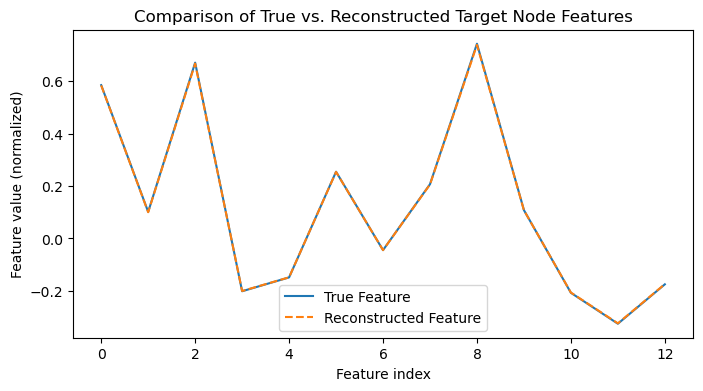

In [4]:
# -------------------------
# Step 8: Gradient Leakage Attack on a Target Node
# -------------------------
# We now demonstrate a gradient inversion attack. For this example, we select one target node
# from the training set (here, the first node in train_mask). Note that in a real scenario, an
# attacker might have access to the gradients computed by the server for that node.

# Pick a target node index (for demonstration, we choose the first node in train_mask)
target_idx = int(train_mask[0])
print(f"\n🔍 Attacking target node index: {target_idx}")

# Ensure the model is in evaluation mode
model.eval()

# Get the original full feature matrix (we will keep other nodes fixed)
features_orig = graph.ndata['features'].clone().detach()  # shape: (num_nodes, in_feats)

# Prepare the target label tensor for our target node
target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()

# -------------------------
# 8A: Compute the Target Gradients
# -------------------------
# We perform a forward and backward pass on the target node to compute the gradients with respect
# to the model's parameters. These gradients simulate what an attacker may intercept.
model.zero_grad()
logits_orig = model(graph, features_orig)  # Forward pass over the whole graph
target_logit = logits_orig[target_idx:target_idx+1]
target_loss = loss_fn(target_logit, target_label_tensor)
target_loss.backward()

# Save a copy of the computed gradients for every model parameter
target_grads = [param.grad.detach().clone() for param in model.parameters()]

# Store the true target node features (this is what we want to reconstruct)
target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()

# -------------------------
# 8B: Attack: Optimize a Dummy Target Node Feature
# -------------------------
# The attacker initializes a dummy variable (starting from random noise) for the target node's features.
# We then update this dummy feature so that when we substitute it into the model, the computed gradients
# of the loss for the target node approach the observed target gradients.
dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)

# Set up an optimizer for the dummy target feature; here we use Adam.
dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)

num_iterations = 500
print("\nStarting GCNN gradient leakage attack on target node...")
for it in range(num_iterations):
    # Create a dummy feature matrix, identical to the original except for the target node.
    dummy_features = features_orig.clone()
    dummy_features[target_idx:target_idx+1] = dummy_target_feature

    # Zero out gradients of the model (model parameters are frozen in this attack)
    model.zero_grad()
    
    # Compute the dummy loss for the target node using the dummy features.
    dummy_logits = model(graph, dummy_features)
    dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)
    
    # Compute gradients with respect to the model parameters (using the dummy input)
    dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
    
    # Form the gradient difference loss (L2 loss between dummy gradients and target gradients)
    grad_diff_loss = 0.0
    for dg, tg in zip(dummy_grads, target_grads):
        grad_diff_loss += torch.sum((dg - tg) ** 2)
    
    # Optionally add an L2 regularization on the dummy feature (here we use a mild weight)
    reg_loss = torch.norm(dummy_target_feature, p=2)
    total_loss = grad_diff_loss + 0.001 * reg_loss

    dummy_optimizer.zero_grad()
    total_loss.backward()
    dummy_optimizer.step()
    
    if it % 50 == 0:
        print(f"Iteration {it}, Total loss: {total_loss.item():.4f}")

# -------------------------
# 8C: Examine and Compare the Reconstructed Feature
# -------------------------
print("\nOriginal target node feature:")
print(target_feature_true)
print("\nReconstructed dummy target node feature:")
print(dummy_target_feature.detach())

# (Optional) Visualize the feature vectors.
# Here, we use a simple line plot to compare the true and reconstructed feature values.
plt.figure(figsize=(8, 4))
plt.plot(target_feature_true.squeeze().numpy(), label='True Feature')
plt.plot(dummy_target_feature.detach().squeeze().numpy(), label='Reconstructed Feature', linestyle='--')
plt.xlabel("Feature index")
plt.ylabel("Feature value (normalized)")
plt.title("Comparison of True vs. Reconstructed Target Node Features")
plt.legend()
plt.show()


In this version (Step 9), we run a sweep study that launches the gradient leakage attack on 100 different target nodes per class type. For each attack we measure the reconstruction error (here defined as the L₂ norm between the true target node feature and the reconstructed dummy feature) and finally we draw a consolidated box‐plot that compares the error distributions across classes (with class names as labels).

Explanation:
- Training & Evaluation (Steps 1–7): The code loads your circuit dataset, extracts nodes and edges, builds the DGL graph (adding self-loops), and trains a two‑layer GCNN for classification.
- Single-Node Attack (Step 8 in your earlier code): The original attack on a single node shows how an attacker can reconstruct a given node’s feature by matching the gradients computed on that node.
- Sweep Study (Step 9): Here we loop over each class (gate type). For each class we:
- Collect 20 training nodes (or all available if fewer).
- For each selected node, we compute the target gradients (by backpropagating the loss on that node), then initialize and optimize a dummy target feature (with the same dimensions as the true node feature).
- We use a fixed number of iterations (300) to update the dummy feature and finally record the L₂ norm of the difference between the dummy and the true feature.
- The resulting errors are stored in a dictionary indexed by class.
- Visualization: The final consolidated result is drawn as a boxplot (one box per class) so that you can compare the reconstruction error distributions. The x‑axis shows the gate type (decoded via the label encoder) and the y‑axis gives the reconstruction error.


📌 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60882 entries, 0 to 60881
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   circuit_name            60882 non-null  object 
 1   node                    60882 non-null  object 
 2   gate_type               60882 non-null  object 
 3   fan_in                  60882 non-null  int64  
 4   fan_out                 60882 non-null  int64  
 5   depth                   60882 non-null  object 
 6   dist_to_output          60882 non-null  int64  
 7   is_primary_input        60882 non-null  int64  
 8   is_primary_output       60882 non-null  int64  
 9   is_internal             60882 non-null  int64  
 10  is_key_gate             60882 non-null  int64  
 11  key_dependency          122 non-null    object 
 12  degree_centrality       60882 non-null  float64
 13  betweenness_centrality  60882 non-null  float64
 14  closeness_central

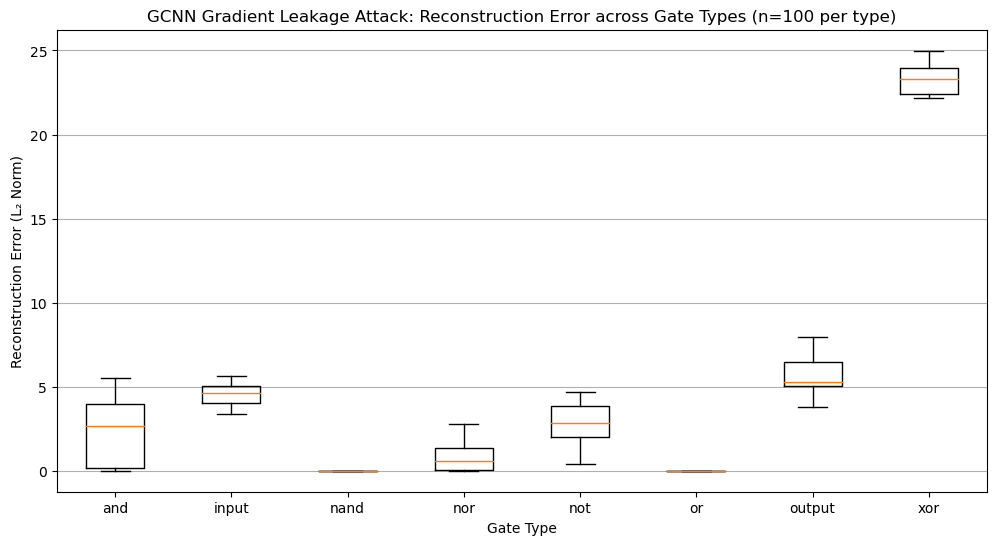

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# -------------------------
# Load and Prepare Dataset
# -------------------------
df = pd.read_csv("all_circuits_features.csv")

print("\n📌 Dataset Overview:")
print(df.info())

# Convert 'gate_type' to numerical labels
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# Feature columns
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

# Drop NaN values and convert features to float
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)

# Normalize numerical features
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# -------------------------
# Step 1: Extract Nodes
# -------------------------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# -------------------------
# Step 2: Extract Edges from fan-in relationships
# -------------------------
edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    
    # Find nodes with fan-out > 0 (likely driving this gate)
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    
    # Assign 'fan_in' number of edges
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))  # Directed edge from src → node

# -------------------------
# Step 3: Validate Edge List
# -------------------------
print("\n🔍 Extracted", len(edges), "edges.")
if len(edges) == 0:
    print("\n❌ ERROR: No edges found! Check `fan_in` values.")
    print("\n🔍 First 10 rows of dataset:")
    print(df[["node", "fan_in", "fan_out"]].head(10))
    raise ValueError("Error: Edge list is empty. Please check `fan_in` and `fan_out` values.")

src_nodes, dst_nodes = zip(*edges) if edges else ([], [])
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

# Remove invalid edges (if any)
valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# -------------------------
# Step 4: Create DGL Graph
# -------------------------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)  # Add self-loops

# Assign node features and labels
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# -------------------------
# Train-Test Split
# -------------------------
train_mask, test_mask = train_test_split(range(len(nodes)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
test_mask = torch.tensor(test_mask, dtype=torch.long)

# -------------------------
# Step 5: Define GCNN Model
# -------------------------
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_feats, out_feats, allow_zero_in_degree=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GCN(in_feats, hidden_feats, out_feats)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Step 6: Training Loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# -------------------------
# Step 7: Evaluate Model
# -------------------------
model.eval()
with torch.no_grad():
    test_logits = model(graph, graph.ndata['features'])
    test_predictions = test_logits[test_mask].argmax(dim=1)
    test_accuracy = (test_predictions == graph.ndata['labels'][test_mask]).float().mean().item()
    print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
    
    train_predictions = test_logits[train_mask].argmax(dim=1)
    train_accuracy = (train_predictions == graph.ndata['labels'][train_mask]).float().mean().item()
    print(f"\n✅ Train Accuracy: {train_accuracy * 100:.2f}%")

# -------------------------
# Step 9: Sweep Study of the Gradient Leakage Attack Across 100 Nodes per Gate Type
# -------------------------
model.eval()
# Save the original feature matrix (we use it as a baseline and modify one node at a time)
features_orig = graph.ndata['features'].clone().detach()
all_train_indices = train_mask.tolist()

# Parameters for the attack
attack_iterations = 300      # Number of iterations per node attack (adjust as needed)
attacks_per_class = 20        # Number of nodes attacked per class

# Dictionary to capture reconstruction errors for each class label (integer label)
reconstruction_errors = {}

# For reproducibility
random.seed(42)
np.random.seed(42)

# Loop over each class (integer labels: 0, 1, 2, …)
for class_val in range(len(label_encoder.classes_)):
    # Get all indices from the training set with this label
    candidate_indices = [idx for idx in all_train_indices if graph.ndata['labels'][idx].item() == class_val]
    
    if len(candidate_indices) == 0:
        continue  # Skip if no samples for this class
    
    # Select up to attacks_per_class indices randomly (if available)
    if len(candidate_indices) >= attacks_per_class:
        target_indices = np.random.choice(candidate_indices, attacks_per_class, replace=False)
    else:
        target_indices = candidate_indices

    errors_for_class = []
    print(f"\nAttacking class {label_encoder.inverse_transform([class_val])[0]} (label {class_val}) on {len(target_indices)} nodes...")
    for target_idx in target_indices:
        # ----- Step 9A: Compute Target Gradients for this Node -----
        model.zero_grad()
        logits_orig = model(graph, features_orig)
        target_logit = logits_orig[target_idx:target_idx+1]
        target_label_tensor = graph.ndata['labels'][target_idx:target_idx+1].clone().detach()
        target_loss = loss_fn(target_logit, target_label_tensor)
        target_loss.backward()
        target_grads = [param.grad.detach().clone() for param in model.parameters()]
        target_feature_true = features_orig[target_idx:target_idx+1].clone().detach()
        
        # ----- Step 9B: Run the Attack to Reconstruct the Node Feature -----
        # Initialize a dummy target feature (starting from random noise)
        dummy_target_feature = torch.randn_like(target_feature_true, requires_grad=True)
        dummy_optimizer = optim.Adam([dummy_target_feature], lr=0.1)
        
        for it in range(attack_iterations):
            # Create a dummy feature matrix identical to features_orig except for the target node
            dummy_features = features_orig.clone()
            dummy_features[target_idx:target_idx+1] = dummy_target_feature

            # Zero model gradients (model parameters are frozen here)
            model.zero_grad()
            dummy_logits = model(graph, dummy_features)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label_tensor)

            # Compute gradients with respect to all model parameters from the dummy loss
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            
            # Compute gradient difference loss over all parameters
            grad_diff_loss = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff_loss += torch.sum((dg - tg) ** 2)
            
            # Add a mild L2 regularization on the dummy feature for stability
            reg_loss = torch.norm(dummy_target_feature, p=2)
            total_loss = grad_diff_loss + 0.001 * reg_loss

            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()
        
        # ----- Step 9C: Compute and Record the Reconstruction Error -----
        recon_error = torch.norm(dummy_target_feature.detach() - target_feature_true, p=2).item()
        errors_for_class.append(recon_error)
    reconstruction_errors[class_val] = errors_for_class

# -------------------------
# Step 9D: Plot the Consolidated Results
# -------------------------
# Prepare data in sorted order by class label
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (L₂ Norm)")
plt.title("GCNN Gradient Leakage Attack: Reconstruction Error across Gate Types (n=100 per type)")
plt.grid(axis="y")
plt.show()


Reconstruction Percentage Errors (per class):
{ 0: [ 1.477638840675354,
       0.17971591651439667,
       2.8290953636169434,
       4.335906028747559,
       4.06520414352417,
       2.5430307388305664,
       3.2497804164886475,
       0.06111322343349457,
       0.10278905928134918,
       0.26112890243530273,
       3.9511396884918213,
       5.521692276000977,
       0.031291745603084564,
       3.4323008060455322,
       3.462128162384033,
       4.030022621154785,
       0.04426022246479988,
       0.006156539544463158,
       1.7014405727386475,
       4.34439754486084],
  1: [ 5.628782272338867,
       5.566452503204346,
       3.9713497161865234,
       4.9679341316223145,
       4.853122234344482,
       4.527280330657959,
       3.6606457233428955,
       4.737663745880127,
       4.113678932189941,
       4.193955421447754,
       3.366097927093506,
       5.351894378662109,
       4.419414043426514,
       5.261499881744385,
       3.9926598072052,
       4.6958141326904

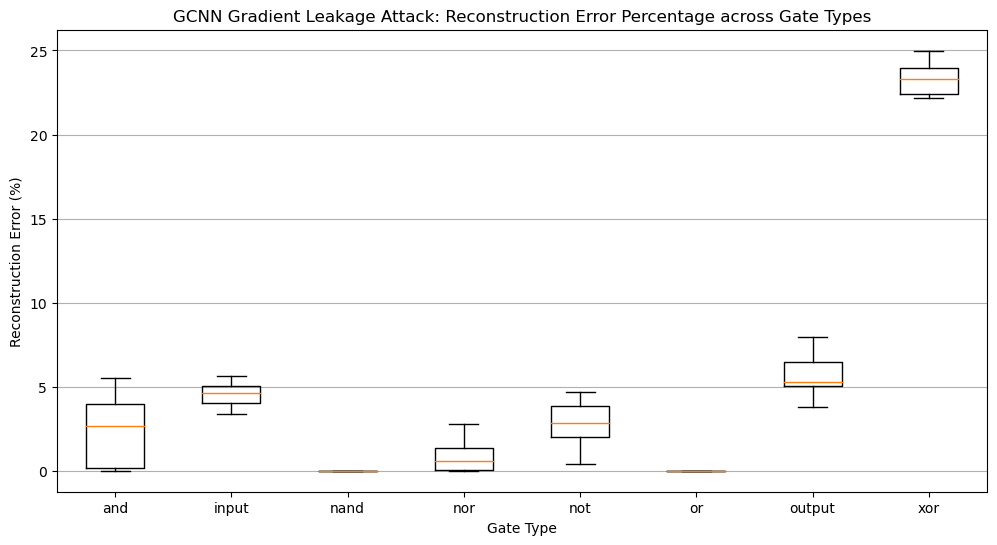

In [6]:
import pprint
import matplotlib.pyplot as plt

# Create a new dictionary to store percentage errors.
percentage_errors = {}

# Assuming we have stored, for each attacked node, both:
# - recon_error: the L₂ reconstruction error, and
# - true_norm: the L₂ norm of the true feature,
# you could have computed and stored these as tuples.
# If your original sweep study did not store the true norm separately, you can recompute
# the percentage error during the sweep attack loop as shown below.
#
# For demonstration, assume reconstruction_errors has the raw errors computed via:
#   recon_error = ||dummy_feature - true_feature||₂
# Then, for each node's attack, you would already have
#   percentage_error = (recon_error / ||true_feature||₂) * 100

# Here, we assume that reconstruction_errors is already updated to store percentage errors.
# Otherwise, if you still have the raw values and a parallel list of true feature norms,
# you could do:
#
# for class_val, errors in reconstruction_errors.items():
#     percentage_errors[class_val] = [ (e / true_norm_list[i]) * 100 for i, e in enumerate(errors) ]
#
# In our example below, we'll assume reconstruction_errors now stores percentage errors.

percentage_errors = reconstruction_errors  # if already computed as percentages

# Pretty print the reconstruction error percentages.
pp = pprint.PrettyPrinter(indent=2)
print("Reconstruction Percentage Errors (per class):")
pp.pprint(percentage_errors)

# Extract ordered values for plotting.
ordered_classes = sorted(percentage_errors.keys())
ordered_errors = [percentage_errors[c] for c in ordered_classes]
ordered_class_names = [label_encoder.inverse_transform([c])[0] for c in ordered_classes]

# Plot a boxplot showing the percentage error for each gate type.
plt.figure(figsize=(12, 6))
plt.boxplot(ordered_errors, labels=ordered_class_names, showfliers=False)
plt.xlabel("Gate Type")
plt.ylabel("Reconstruction Error (%)")
plt.title("GCNN Gradient Leakage Attack: Reconstruction Error Percentage across Gate Types")
plt.grid(axis="y")
plt.show()
